In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Set display options
# pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 190)
plt.style.use('seaborn-v0_8-darkgrid')

In [36]:
data = pd.read_excel('cleaned_data.xlsx')

data['Transaction Date'] = pd.to_datetime(data['Transaction Date'])

columns_needed = [
    'Client number', 'Product Name', 'Product Type',
    'Transaction Date', 'Transaction Amount (SGD)',
    'Fund House/Issuer/Exchange', 'Product Category/DPMS Risk Level/Company Portfolio Risk Level'
]
df = data[columns_needed].copy()

df.columns = ['Client', 'Product', 'ProductType', 'Date', 'Amount', 'Issuer', 'Category']

df = df.sort_values(['Client', 'Date']).reset_index(drop=True)

In [45]:
print(f'Dataset Shape: {df.shape}')
print(f'Date Range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Unique Clients: {df["Client"].nunique()}')
print(f'Products: {df["Product"].nunique()}')
print(f'Transaction Amount Statistics:')
df['Amount'].describe()

Dataset Shape: (3171, 7)
Date Range: 2021-09-01 to 2025-09-26
Unique Clients: 190
Products: 566
Transaction Amount Statistics:


count    3.171000e+03
mean     1.933195e+04
std      5.212408e+04
min      7.703000e+01
25%      2.655490e+03
50%      6.250000e+03
75%      1.859401e+04
max      1.000582e+06
Name: Amount, dtype: float64

In [39]:
df

,Client,Product,ProductType,Date,Amount,Issuer,Category
0,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2021-10-29,3500.00,-,Aggressive
1,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-02-28,2000.00,-,Aggressive
2,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-06-02,5000.00,-,Aggressive
3,B1,DigiCore Reit USD,STOCK,2022-08-18,249.85,SGX,Equity
4,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-08-18,3000.00,-,Aggressive
...,...,...,...,...,...,...,...
3166,B97,STI ETF,ETF,2023-03-20,3199.40,State Street Global Advisors,Equity
3167,B97,Vanguard S&P 500 ETF,ETF,2023-03-20,1941.99,Vanguard,Equity
3168,B98,ETFMG Prime Mobile Payments ETF,ETF,2022-03-22,2154.32,ETF Managers Group LLC,Equity
3169,B98,Apple,STOCK,2023-03-06,2095.90,NASDAQ,Equity


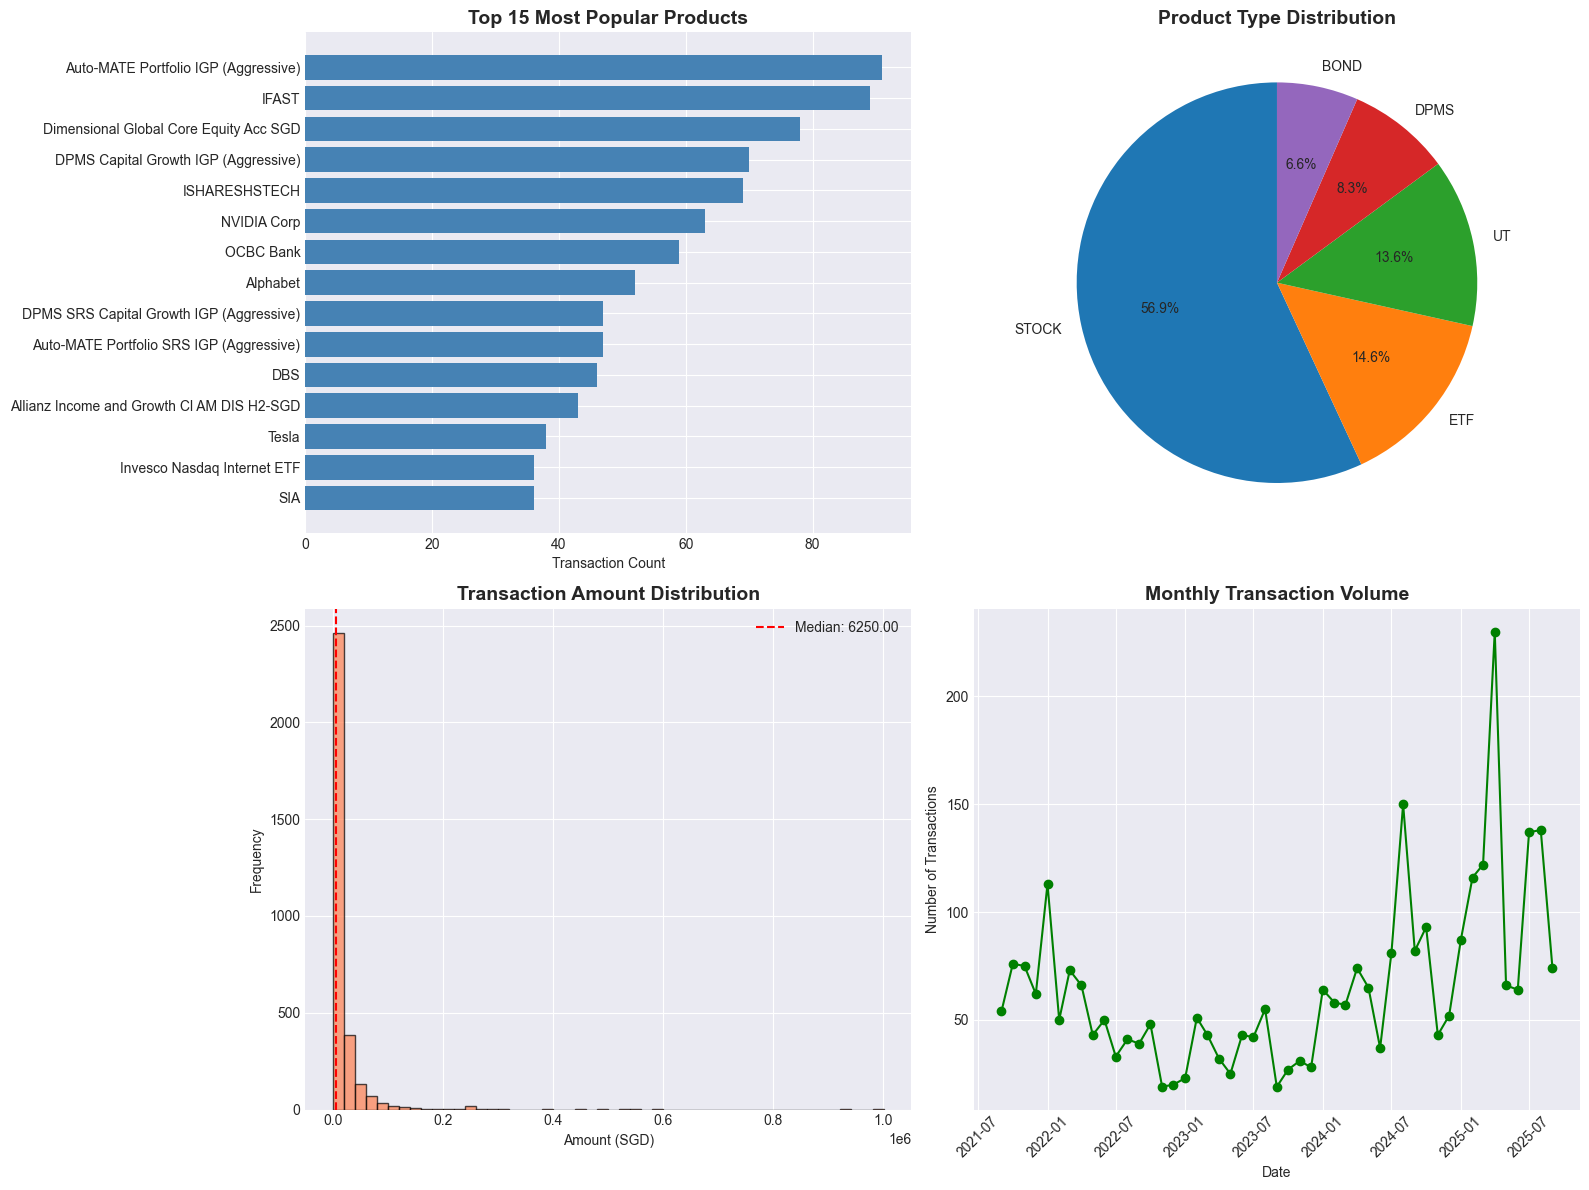

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_products = df['Product'].value_counts().head(15)
axes[0, 0].barh(top_products.index[::-1], top_products.values[::-1], color='steelblue')
axes[0, 0].set_title('Top 15 Most Popular Products', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Transaction Count')

product_type_counts = df['ProductType'].value_counts()
axes[0, 1].pie(product_type_counts, labels=product_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Product Type Distribution', fontsize=14, fontweight='bold')

axes[1, 0].hist(df['Amount'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Amount (SGD)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['Amount'].median(), color='red', linestyle='--', label=f"Median: {df['Amount'].median():.2f}")
axes[1, 0].legend()

monthly_transactions = df.groupby(df['Date'].dt.to_period('M')).size()
axes[1, 1].plot(monthly_transactions.index.to_timestamp(), monthly_transactions.values, marker='o', color='green')
axes[1, 1].set_title('Monthly Transaction Volume', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [42]:
print("Client-Level Statistics:"),
client_stats = df.groupby('Client').agg({
    'Product': 'count',
    'Amount': ['sum', 'mean', 'median'],
    'Date': lambda x: (x.max() - x.min()).days
}).round(2)
client_stats.columns = ['Num_Transactions', 'Total_Invested', 'Avg_Amount', 'Median_Amount', 'Days_Active']
client_stats.describe()

Client-Level Statistics:


,Num_Transactions,Total_Invested,Avg_Amount,Median_Amount,Days_Active
count,190.000000,1.900000e+02,190.000000,190.000000,190.000000
mean,16.689474,3.226400e+05,27987.198895,24136.528526,520.042105
std,28.927082,7.810320e+05,66796.599234,71081.977784,554.565074
min,1.000000,5.000000e+02,166.670000,100.000000,0.000000
25%,2.000000,2.000000e+04,4998.282500,4168.262500,0.000000
50%,6.000000,9.372789e+04,13490.225000,10500.120000,292.500000
75%,14.000000,2.620981e+05,28265.782500,23020.040000,1109.750000
max,184.000000,5.874250e+06,820498.670000,937000.000000,1479.000000


Feature Engineering

In [49]:
client_features = df.groupby('Client').agg({
    'Amount': ['mean', 'median', 'std', 'sum', 'count'],
    'Date': ['min', 'max'],
    'Product': lambda x: x.nunique(),
    'ProductType': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'STOCK'
}).reset_index()

client_features.columns = [
    'Client', 'Avg_Amount', 'Median_Amount', 'Std_Amount', 'Total_Invested', 
    'Num_Transactions', 'First_Transaction', 'Last_Transaction', 
    'Unique_Products', 'Favorite_ProductType'
]

client_features['Days_Active'] = (client_features['Last_Transaction'] - client_features['First_Transaction']).dt.days
client_features['Avg_Days_Between_Purchases'] = client_features['Days_Active'] / (client_features['Num_Transactions'] - 1)
client_features['Avg_Days_Between_Purchases'] = client_features['Avg_Days_Between_Purchases'].fillna(30)  # Default 30 days for single transaction

print("Client Features:")
client_features
client_features.head(20)

Client Features:


,Client,Avg_Amount,Median_Amount,Std_Amount,Total_Invested,Num_Transactions,First_Transaction,Last_Transaction,Unique_Products,Favorite_ProductType,Days_Active,Avg_Days_Between_Purchases
0,B1,1827.763750,1241.015,1847.713183,14622.11,8,2021-10-29,2022-09-01,4,DPMS,307,43.857143
1,B10,44893.016700,25514.280,49273.928380,4489301.67,100,2021-09-07,2025-09-25,30,STOCK,1479,14.939394
2,B100,674.086000,593.190,310.930473,3370.43,5,2022-04-05,2022-08-18,5,ETF,135,33.750000
3,B101,10074.420000,10074.420,NaN,10074.42,1,2022-04-08,2022-04-08,1,ETF,0,30.000000
4,B102,35301.870000,30601.910,22719.428171,105905.61,3,2022-04-12,2024-04-01,3,DPMS,720,360.000000
5,B103,30325.692500,22997.775,21054.349403,121302.77,4,2022-04-12,2025-04-01,3,DPMS,1085,361.666667
6,B104,80096.200000,80096.200,70968.064987,160192.40,2,2022-04-19,2022-06-23,1,BOND,65,65.000000
7,B105,4376.980000,4376.980,1072.553708,8753.96,2,2022-04-25,2025-04-10,1,STOCK,1081,1081.000000
8,B106,27577.000000,27577.000,NaN,27577.00,1,2022-05-06,2022-05-06,1,STOCK,0,30.000000
9,B107,50000.000000,50000.000,NaN,50000.00,1,2022-05-12,2022-05-12,1,DPMS,0,30.000000


In [50]:
product_features = df.groupby('Product').agg({
    'Amount': ['mean', 'median', 'count'],
    'Client': lambda x: x.nunique()
}).reset_index()

product_features.columns = ['Product', 'Avg_Product_Amount', 'Median_Product_Amount', 'Product_Popularity', 'Unique_Buyers']

print("Product Features Created:")
product_features.head(20)

Product Features Created:


,Product,Avg_Product_Amount,Median_Product_Amount,Product_Popularity,Unique_Buyers
0,$ Beverly JCG,209.010000,209.010,1,1
1,$ Biolidics R,509.150000,509.150,1,1
2,$ CNMC Goldmine,4880.816667,4661.130,3,2
3,$ Healthway Med,981.340000,981.340,1,1
4,$ Zixin,4709.530000,4709.530,1,1
5,2X LONG SUPER MICRO COMPUTER (SMCI) ETP,317.770000,317.770,2,1
6,2x Bitcoin Strategy ETF,7096.107500,3924.435,8,1
7,ABC,3719.300000,3719.300,1,1
8,AEM,2096.960000,2096.960,1,1
9,AEM SGD,3550.562000,3510.530,5,3


In [51]:
df_enhanced = df.merge(client_features[['Client', 'Avg_Amount', 'Num_Transactions', 'Avg_Days_Between_Purchases']], on='Client')
df_enhanced = df_enhanced.merge(product_features[['Product', 'Avg_Product_Amount', 'Product_Popularity']], on='Product')

df_enhanced['DayOfWeek'] = df_enhanced['Date'].dt.dayofweek
df_enhanced['Month'] = df_enhanced['Date'].dt.month
df_enhanced['Quarter'] = df_enhanced['Date'].dt.quarter

df_enhanced.shape

(3171, 15)

In [53]:
client_sequences = df.groupby('Client')['Product'].apply(list).reset_index()
client_sequences.columns = ['Client', 'ProductSequence']

transitions = []
for idx, row in df.iterrows():
    client = row['Client']
    current_product = row['Product']
    
    next_transaction = df[(df['Client'] == client) & (df['Date'] > row['Date'])].sort_values('Date').head(1)
    
    if not next_transaction.empty:
        next_product = next_transaction.iloc[0]['Product']
        transitions.append({
            'From_Product': current_product,
            'To_Product': next_product,
            'Client': client
        })

transitions_df = pd.DataFrame(transitions)
transitions_df

,From_Product,To_Product,Client
0,DPMS Capital Growth IGP (Aggressive),DPMS Capital Growth IGP (Aggressive),B1
1,DPMS Capital Growth IGP (Aggressive),DPMS Capital Growth IGP (Aggressive),B1
2,DPMS Capital Growth IGP (Aggressive),DigiCore Reit USD,B1
3,DigiCore Reit USD,ISHARESHSTECH,B1
4,DPMS Capital Growth IGP (Aggressive),ISHARESHSTECH,B1
...,...,...,...
2890,ISHARESCSI300,ISHARESHSTECH,B97
2891,ISHARESHSTECH,Invesco Actively Managed Exch-Traded Commodity...,B97
2892,Invesco Actively Managed Exch-Traded Commodity...,ISHARESHSI,B97
2893,ISHARESHSI,Invesco KBW Bank ETF,B97


In [54]:
transition_counts = transitions_df.groupby(['From_Product', 'To_Product']).size().reset_index(name='Count')
total_from = transitions_df.groupby('From_Product').size().reset_index(name='Total')
transition_probs = transition_counts.merge(total_from, on='From_Product')
transition_probs['Probability'] = transition_probs['Count'] / transition_probs['Total']
transition_probs = transition_probs.sort_values('Probability', ascending=False)

print("Sequential Transitions Calculated")
print(f"Total transitions found: {len(transitions_df)}")
print("Top 10 Product Transitions:")
transition_probs.head(10)[['From_Product', 'To_Product', 'Count', 'Probability']]

Sequential Transitions Calculated
Total transitions found: 2895
Top 10 Product Transitions:


,From_Product,To_Product,Count,Probability
0,$ Beverly JCG,IFAST,1,1.0
1009,MEITUA 2.125% 28Oct2025 Corp (USD),CATHAY 3.375% 22Jan2023 Corp (SGD),1,1.0
985,LI NING,JIANGXI COPPER,1,1.0
991,LION-PHILLIP S-REIT,Auto-MATE Portfolio IGP (Aggressive),1,1.0
995,Legg Mason ClearBridge - Global Infrastructure...,DWS Invest Global Infrastructure LDMH(P) SGD,1,1.0
996,Lendlease Reit,MCTSP 3.110% 24Aug2026 Corp (SGD),3,1.0
997,Lippo Malls Tr,BABA-SW,1,1.0
1007,Luminar Technologies,Gores Guggenheim,1,1.0
1008,MCTSP 3.110% 24Aug2026 Corp (SGD),MCTSP 3.110% 24Aug2026 Corp (SGD),1,1.0
1012,MMTec,MMTec,5,1.0


In [56]:
basket = df.groupby('Client')['Product'].apply(list).reset_index()

te = TransactionEncoder()
te_ary = te.fit(basket['Product']).transform(basket['Product'])
basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Basket shape: {basket_encoded.shape}")

min_support = 0.02  # At least 2% of clients bought this combination
frequent_itemsets = apriori(basket_encoded, min_support=min_support, use_colnames=True)

print(f"Found {len(frequent_itemsets)} frequent itemsets with min_support={min_support}")

Basket shape: (190, 566)
Found 503 frequent itemsets with min_support=0.02


Generated 1793 association rules


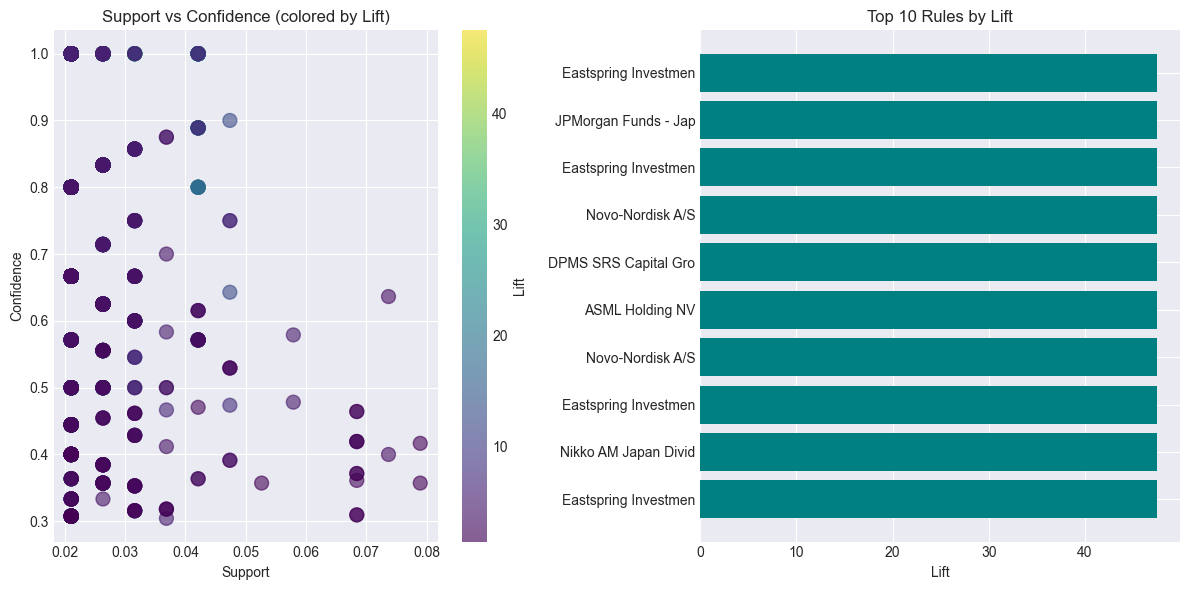

In [62]:
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"Generated {len(rules)} association rules")

    if len(rules) > 0:
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.scatter(rules['support'], rules['confidence'], alpha=0.6, c=rules['lift'], cmap='viridis', s=100)
        plt.colorbar(label='Lift')
        plt.xlabel('Support')
        plt.ylabel('Confidence')
        plt.title('Support vs Confidence (colored by Lift)')
        
        plt.subplot(1, 2, 2)
        top_10_rules = rules.head(10)
        plt.barh(range(len(top_10_rules)), top_10_rules['lift'], color='teal')
        plt.yticks(range(len(top_10_rules)), [f"{list(r['antecedents'])[0][:20]}"for _, r in top_10_rules.iterrows()])
        plt.xlabel('Lift')
        plt.title('Top 10 Rules by Lift')
        plt.tight_layout()
        plt.show()
    else:
        rules = pd.DataFrame()

In [61]:
print("Top 10 Association Rules (by Lift):")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Top 10 Association Rules (by Lift):


,antecedents,consequents,support,confidence,lift
700,(Eastspring Investments - Japan Dynamic AJ JPY...,(JPMorgan Funds - Japan Equity A (acc) JPY),0.021053,1.0,47.5
704,(Nikko AM Japan Dividend Equity JPY),(Eastspring Investments - Japan Dynamic AJ JPY...,0.021053,1.0,47.5
699,(Eastspring Investments - Japan Dynamic AJ JPY...,(Nikko AM Japan Dividend Equity JPY),0.021053,1.0,47.5
1403,"(Novo-Nordisk A/S, Auto-MATE Portfolio SRS IGP...","(ASML Holding NV, DPMS SRS Capital Growth IGP ...",0.021053,1.0,47.5
1409,"(ASML Holding NV, DPMS SRS Capital Growth IGP ...","(Novo-Nordisk A/S, Auto-MATE Portfolio SRS IGP...",0.021053,1.0,47.5
1744,"(DPMS SRS Capital Growth IGP (Aggressive), ETF...","(BACR 8.300% Perpetual Corp (SGD), IFAST)",0.021053,1.0,47.5
1414,"(Novo-Nordisk A/S, Auto-MATE Portfolio SRS IGP...","(ASML Holding NV, DPMS SRS Capital Growth IGP ...",0.021053,1.0,47.5
138,(Eastspring Investments - Japan Dynamic AJ JPY),(JPMorgan Funds - Japan Equity A (acc) JPY),0.021053,1.0,47.5
139,(JPMorgan Funds - Japan Equity A (acc) JPY),(Eastspring Investments - Japan Dynamic AJ JPY),0.021053,1.0,47.5
140,(Eastspring Investments - Japan Dynamic AJ JPY),(Nikko AM Japan Dividend Equity JPY),0.021053,1.0,47.5


MAE: 10,865.03
RMSE: 42,497.75
R²: 0.454
MAPE: 1.692
Feature Importance:
               Feature  Importance
2   Avg_Product_Amount    0.436420
0           Avg_Amount    0.319616
5                Month    0.099916
1     Num_Transactions    0.043338
4            DayOfWeek    0.038889
3   Product_Popularity    0.026686
6              Quarter    0.019536
7  ProductType_Encoded    0.015600


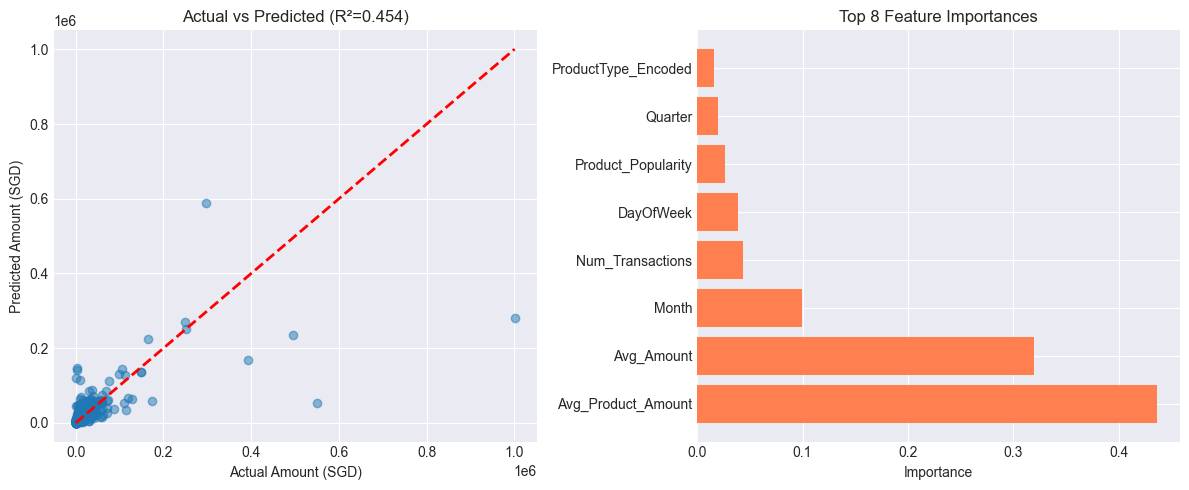

In [63]:
amount_features = df_enhanced[[
    'Avg_Amount', 'Num_Transactions', 'Avg_Product_Amount', 
    'Product_Popularity', 'DayOfWeek', 'Month', 'Quarter'
]].copy()

le_product = LabelEncoder()
amount_features['ProductType_Encoded'] = le_product.fit_transform(df_enhanced['ProductType'])

y_amount = df_enhanced['Amount']

X_train_amt, X_test_amt, y_train_amt, y_test_amt = train_test_split(
    amount_features, y_amount, test_size=0.2, random_state=42
)

rf_amount = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_amount.fit(X_train_amt, y_train_amt)

y_pred_amt = rf_amount.predict(X_test_amt)

mae = mean_absolute_error(y_test_amt, y_pred_amt)
rmse = np.sqrt(mean_squared_error(y_test_amt, y_pred_amt))
r2 = r2_score(y_test_amt, y_pred_amt)
mape = mean_absolute_percentage_error(y_test_amt, y_pred_amt)
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.3f}")
print(f"MAPE: {mape:.3f}")

feature_importance = pd.DataFrame({
    'Feature': amount_features.columns,
    'Importance': rf_amount.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test_amt, y_pred_amt, alpha=0.5)
plt.plot([y_test_amt.min(), y_test_amt.max()], [y_test_amt.min(), y_test_amt.max()], 'r--', lw=2)
plt.xlabel('Actual Amount (SGD)')
plt.ylabel('Predicted Amount (SGD)')
plt.title(f'Actual vs Predicted (R²={r2:.3f})')

plt.subplot(1, 2, 2)
plt.barh(feature_importance['Feature'][:8], feature_importance['Importance'][:8], color='coral')
plt.xlabel('Importance')
plt.title('Top 8 Feature Importances')
plt.tight_layout()
plt.show()

In [67]:
df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

next_purchase_predictions = []

for client in client_features['Client'].unique():
    client_data = df_sorted[df_sorted['Client'] == client]
    
    if len(client_data) >= 2:
        # Get last transaction date
        last_transaction_date = client_data['Date'].max()
        
        # Calculate average days between purchases (excluding first transaction)
        avg_interval = client_data['Days_Since_Last'].dropna().mean()
        median_interval = client_data['Days_Since_Last'].dropna().median()
        
        # Predict next purchase date (using median for robustness)
        predicted_next_date = last_transaction_date + timedelta(days=median_interval)
        
        next_purchase_predictions.append({
            'Client': client,
            'Last_Transaction_Date': last_transaction_date,
            'Avg_Days_Between': avg_interval,
            'Median_Days_Between': median_interval,
            'Predicted_Next_Purchase_Date': predicted_next_date,
            #! 'Days_Until_Next_Purchase': (predicted_next_date - pd.Timestamp.now()).days
        })

timing_predictions = pd.DataFrame(next_purchase_predictions)
# timing_predictions = timing_predictions.sort_values('Days_Until_Next_Purchase')

print(f"Timing predictions generated for {len(timing_predictions)} clients")
timing_predictions

Timing predictions generated for 152 clients


,Client,Last_Transaction_Date,Avg_Days_Between,Median_Days_Between,Predicted_Next_Purchase_Date
0,B1,2022-09-01,43.857143,7.0,2022-09-08 00:00:00
1,B10,2025-09-25,14.939394,6.0,2025-10-01 00:00:00
2,B100,2022-08-18,33.750000,22.0,2022-09-09 00:00:00
3,B102,2024-04-01,360.000000,360.0,2025-03-27 00:00:00
4,B103,2025-04-01,361.666667,365.0,2026-04-01 00:00:00
5,B104,2022-06-23,65.000000,65.0,2022-08-27 00:00:00
6,B105,2025-04-10,1081.000000,1081.0,2028-03-26 00:00:00
7,B108,2025-07-14,226.200000,130.0,2025-11-21 00:00:00
8,B109,2025-09-26,16.301370,2.0,2025-09-28 00:00:00
9,B11,2025-07-24,64.363636,16.0,2025-08-09 00:00:00


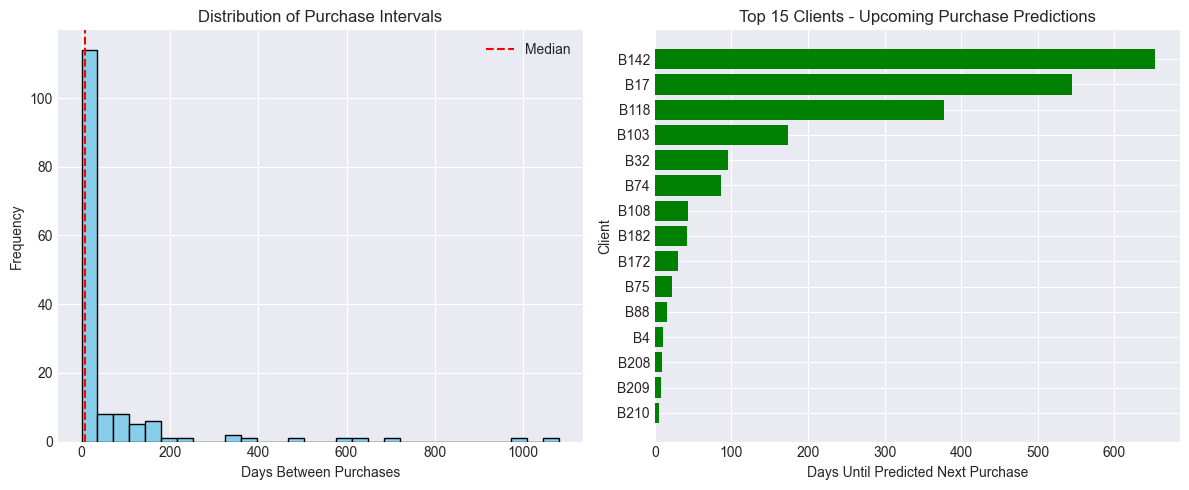

In [69]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(timing_predictions['Median_Days_Between'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Days Between Purchases')
plt.ylabel('Frequency')
plt.title('Distribution of Purchase Intervals')
plt.axvline(timing_predictions['Median_Days_Between'].median(), color='red', linestyle='--', label='Median')
plt.legend()

plt.subplot(1, 2, 2)
# upcoming = timing_predictions[timing_predictions['Days_Until_Next_Purchase'] > 0].head(15)
plt.barh(upcoming['Client'], upcoming['Days_Until_Next_Purchase'], color='green')
plt.xlabel('Days Until Predicted Next Purchase')
plt.ylabel('Client')
plt.title('Top 15 Clients - Upcoming Purchase Predictions')
plt.tight_layout()
plt.show()

In [74]:
recommendations = []

for client in client_features['Client'].unique():
    client_info = client_features[client_features['Client'] == client].iloc[0]
    
    last_product = df[df['Client'] == client].sort_values('Date').iloc[-1]['Product']
    
    # Find next product recommendation using sequential patterns
    next_product_candidates = transition_probs[transition_probs['From_Product'] == last_product].head(1)
    
    if not next_product_candidates.empty:
        recommended_product = next_product_candidates.iloc[0]['To_Product']
        confidence = next_product_candidates.iloc[0]['Probability']
    else:
        # Fallback: Recommend most popular product the client hasn't bought
        client_products = set(df[df['Client'] == client]['Product'])
        all_products = df['Product'].value_counts()
        for prod in all_products.index:
            if prod not in client_products:
                recommended_product = prod
                confidence = 0.5
                break
        else:
            recommended_product = all_products.index[0]
            confidence = 0.3
    
    client_row = df_enhanced[df_enhanced['Client'] == client].iloc[-1]
    features_for_prediction = amount_features.iloc[df_enhanced[df_enhanced['Client'] == client].index[-1]].values.reshape(1, -1)
    predicted_amount = rf_amount.predict(features_for_prediction)[0]
    
    timing_info = timing_predictions[timing_predictions['Client'] == client]
    if not timing_info.empty:
        predicted_date = timing_info.iloc[0]['Predicted_Next_Purchase_Date']
        # days_until = timing_info.iloc[0]['Days_Until_Next_Purchase']
    else:
        predicted_date = pd.Timestamp.now() + timedelta(days=30)
        # days_until = 30
    
    recommendations.append({
        'Client': client,
        'Current_Product': last_product,
        'Recommended_Product': recommended_product,
        'Confidence': f"{confidence:.2%}",
        'Predicted_Amount_SGD': f"{predicted_amount:,.2f}",
        'Predicted_Purchase_Date': predicted_date.date(),
        # 'Days_Until_Purchase': days_until,
        'Avg_Historical_Amount': f"{client_info['Avg_Amount']:,.2f}",
        'Total_Past_Transactions': int(client_info['Num_Transactions'])
    })

recommendations_df = pd.DataFrame(recommendations)
# recommendations_df = recommendations_df.sort_values('Days_Until_Purchase')

print(f"Total clients with recommendations: {len(recommendations_df)}")
recommendations_df.head(20)

Total clients with recommendations: 190


,Client,Current_Product,Recommended_Product,Confidence,Predicted_Amount_SGD,Predicted_Purchase_Date,Avg_Historical_Amount,Total_Past_Transactions
0,B1,CAM HK BANKS,DPMS SRS Capital Growth IGP (Aggressive),33.33%,"1,308.07",2022-09-08,"1,827.76",8
1,B10,Rex Intl,Mapletree Ind Tr,50.00%,"32,410.60",2025-10-01,"44,893.02",100
2,B100,DPMS Capital Growth IGP (Aggressive),DPMS Capital Growth IGP (Aggressive),28.57%,"2,136.20",2022-09-09,674.09,5
3,B101,ISHARESHSTECH,ISHARESHSTECH,15.87%,"9,939.87",2025-11-07,"10,074.42",1
4,B102,Auto-MATE Portfolio SRS IGP (Aggressive),Auto-MATE Portfolio SRS IGP (Aggressive),22.22%,"27,066.00",2025-03-27,"35,301.87",3
5,B103,Auto-MATE Portfolio SRS IGP (Aggressive),Auto-MATE Portfolio SRS IGP (Aggressive),22.22%,"20,821.68",2026-04-01,"30,325.69",4
6,B104,CATHAY 3.375% 22Jan2023 Corp (SGD),DPMS Capital Growth IGP (Aggressive),50.00%,"81,476.40",2022-08-27,"80,096.20",2
7,B105,HSBC HOLDINGS,XPENG-W,50.00%,"3,861.87",2028-03-26,"4,376.98",2
8,B106,ChargePoint Holdings,OCBC Bank,21.43%,"21,890.78",2025-11-07,"27,577.00",1
9,B107,DPMS Capital Growth IGP (Aggressive),DPMS Capital Growth IGP (Aggressive),28.57%,"64,028.01",2025-11-07,"50,000.00",1
